# Battery-Charging Tidal Energy Case Study

This case study demonstrates a representative non-grid-connected battery-charging workflow using VITAL.

The example compares candidate tidal sites and system assumptions using:

- tidal resource data,
- rotor performance data,
- vessel/platform assumptions,
- rotor simulation,
- constraint checks,
- LCOE calculations,
- and design optimization.

The workflow is intended for early-stage screening. Results depend on the selected input data, cost assumptions, and optimization bounds, and should not be interpreted as final design recommendations.

In [1]:
import contextlib
import io
import urllib3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vital.module_tidal import process_tidal_data
from vital.module_rotor import RotorData
from vital.module_rotor_simulation import RotorSimulation
from vital.module_vessel import VesselData
from vital.module_constraint_checker import ConstraintChecker
from vital.module_lcoe import LCOEData, LCOECalculator
from vital.module_lcoe_optimizer import LCOEOptimizer

# Suppress warnings caused by NOAA requests using verify=False internally.
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

plt.style.use("tableau-colorblind10")

## 1. Load rotor performance data

The rotor performance data defines how the turbine behaves as flow conditions change.

The rotor file provides:

- ``TSR``: tip-speed ratio,
- ``Ct``: thrust coefficient, which indicates the hydrodynamic load the rotor places on the system,
- ``Cq``: torque coefficient, which indicates the torque required or produced by the rotor.

VITAL computes the power coefficient internally as:

$$
C_p = TSR \cdot C_q
$$

These curves are used by the simulation to estimate power production and loading.

After loading the rotor data, we add the rotor-specific coefficient functions and operating points to the baseline configuration so ``RotorSimulation`` can use them.

Optimal Cp: 0.2119
Optimal TSR: 0.7648
Estimated TSRmax: 1.7084
Measured TSR range: 0.0526 to 1.7015


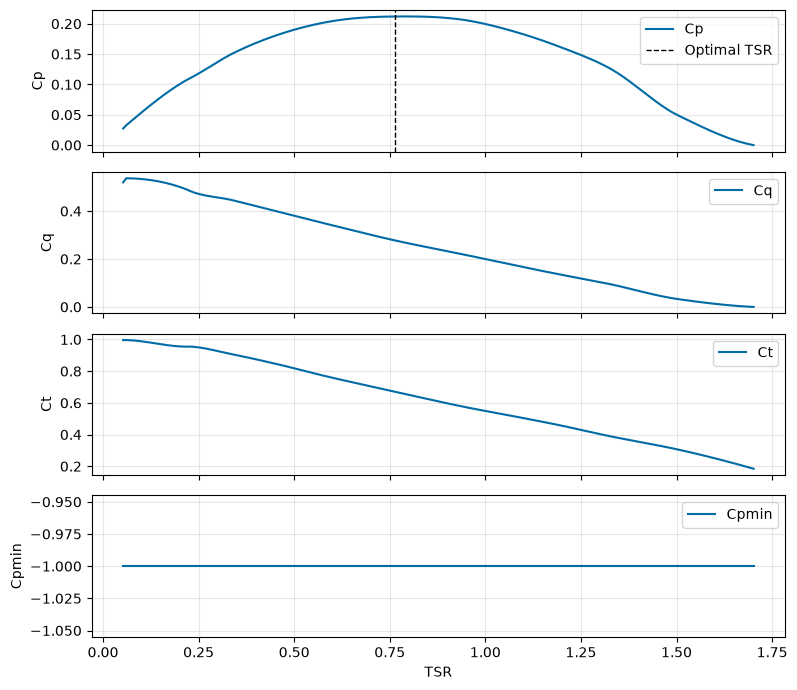

In [2]:
rotor = RotorData(
    filename="../data/Sitkana_rotor_data_blade_2.txt",
)

print(f"Optimal Cp: {rotor.CpOpt:.4f}")
print(f"Optimal TSR: {rotor.TSROpt:.4f}")
print(f"Estimated TSRmax: {rotor.TSRmax:.4f}")
print(f"Measured TSR range: {rotor.tsr.min():.4f} to {rotor.tsr.max():.4f}")

# Plot over the measured TSR range to avoid emphasizing extrapolated behavior.
tsr_vals = np.linspace(rotor.tsr.min(), rotor.tsr.max(), 200)

fig, ax = plt.subplots(4, 1, figsize=(8, 7), sharex=True)

ax[0].plot(tsr_vals, rotor.get_cp(tsr_vals), label="Cp")
ax[0].axvline(rotor.TSROpt, color="k", linestyle="--", linewidth=1, label="Optimal TSR")
ax[0].set_ylabel("Cp")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(tsr_vals, rotor.get_cq(tsr_vals), label="Cq")
ax[1].set_ylabel("Cq")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(tsr_vals, rotor.get_ct(tsr_vals), label="Ct")
ax[2].set_ylabel("Ct")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

ax[3].plot(tsr_vals, rotor.get_cpmin(tsr_vals), label="Cpmin")
ax[3].set_ylabel("Cpmin")
ax[3].set_xlabel("TSR")
ax[3].legend()
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

No separate Cpmin file is supplied in this case study, so ``RotorData`` uses the default $C_{p,\min} = -1.0$ for cavitation checks.

## 2. Baseline design assumptions

To keep the comparison clear, we start with a fixed baseline design.

The baseline design includes:

- rotor size,
- rated power,
- hub depth,
- drivetrain settings,
- vessel/platform geometry,
- generator and power-electronics loss assumptions,
- battery capacity,
- and cost assumptions.

Later, we will compare this baseline design across multiple sites and then test whether the design can be improved through optimization.

This Sitkana case study uses generator and power-electronics loss models to represent non-grid-connected battery-charging operation.

In this example, the loss models are defined as Python callables of generator-side speed and torque:

- ``omega_g``: generator-side angular speed in rad/s
- ``tau``: generator torque in N m

The loss models return power losses in watts. These simplified example models help estimate how much power is lost before energy is delivered to the battery or load.

The example loss models are illustrative and should be replaced with validated hardware-specific generator and power-electronics loss models for design studies.

In [3]:
def generator_loss_model(omega_g, tau):
    """
    Example generator loss model.

    Parameters
    ----------
    omega_g : float or np.ndarray
        Generator-side angular speed (rad/s).
    tau : float or np.ndarray
        Generator torque (N m).

    Returns
    -------
    float or np.ndarray
        Generator loss power (W).
    """
    return 0.137 * np.abs(omega_g) + 3.118 * tau**2


def pe_loss_model(omega_g, tau):
    """
    Example power-electronics loss model.

    Parameters
    ----------
    omega_g : float or np.ndarray
        Generator-side angular speed (rad/s).
    tau : float or np.ndarray
        Generator torque (N m).

    Returns
    -------
    float or np.ndarray
        Power-electronics loss power (W).
    """
    return 5.204 + 0.2896 * np.abs(omega_g) + 0.3559 * np.abs(tau)


baseline_config = {
    # Turbine geometry and ratings
    "Radius": 0.5,                    # Rotor radius (m)
    "Prated": 1000.0,                 # Rated electrical power per turbine (W)
    "Trated": np.inf,                 # Rated generator torque (N m); no torque clipping in this example
    "dHub": 2.0,                      # Hub depth below free surface (m)
    "number_of_turbines": 2,          # Number of turbines in the system

    # Drivetrain and generator parameters
    "Ng": 30,                         # Gear ratio
    "Kt": 1.5,                        # Generator torque constant
    "Rw": 0.5,                        # Generator winding resistance
    "J_d": 1.0,                       # Drivetrain inertia
    "B_d": 0.01,                      # Drivetrain damping/friction
    "J_r": 1.0,                       # Rotor inertia

    # Power-conversion model
    "power_model": "generator_and_pe_loss_models",
    "generator_loss_model": generator_loss_model,
    "pe_loss_model": pe_loss_model,

    # Rotor performance functions
    "CpFunc": rotor.get_cp,
    "CqFunc": rotor.get_cq,
    "CtFunc": rotor.get_ct,
    "CpOpt": rotor.CpOpt,
    "TSROpt": rotor.TSROpt,
    "TSRmax": rotor.TSRmax,
}

print("Baseline turbine configuration defined.")
print(f"  Radius: {baseline_config['Radius']:.2f} m")
print(f"  Rated power per turbine: {baseline_config['Prated'] / 1000:.2f} kW")
print(f"  Hub depth: {baseline_config['dHub']:.2f} m")
print(f"  Number of turbines: {baseline_config['number_of_turbines']}")
print(f"  Power model: {baseline_config['power_model']}")

Baseline turbine configuration defined.
  Radius: 0.50 m
  Rated power per turbine: 1.00 kW
  Hub depth: 2.00 m
  Number of turbines: 2
  Power model: generator_and_pe_loss_models


## 3. Define representative vessel/platform properties

The vessel/platform properties below are used for drag estimation and pitch-constraint checking.

These values are simplified representative inputs for this case study. They should be replaced with site-specific vessel, platform, or mooring data for design studies.

In [4]:
user_vessel_properties = {
    "Xm": 5.77,                       # Horizontal force-application distance (m)
    "Zm": 1.65,                       # Vertical force-application distance (m)
    "Kphi": 1.95e6,                   # Pitch hydrostatic stiffness (N m/rad)
    "theta": np.deg2rad(45.0),        # Mooring line angle (rad)
    "phi": np.deg2rad(20.0),          # Representative pitch angle (rad)
    "area": 9.5,                      # Cross-sectional/projected area (m^2)
    "Cd": 1.0,                        # Drag coefficient
}

print("Representative vessel/platform properties:")
print(f"  Xm: {user_vessel_properties['Xm']:.2f} m")
print(f"  Zm: {user_vessel_properties['Zm']:.2f} m")
print(f"  Kphi: {user_vessel_properties['Kphi']:.3e} N m/rad")
print(f"  Mooring angle theta: {np.rad2deg(user_vessel_properties['theta']):.1f} deg")
print(f"  Pitch angle phi: {np.rad2deg(user_vessel_properties['phi']):.1f} deg")
print(f"  Area: {user_vessel_properties['area']:.2f} m^2")
print(f"  Cd: {user_vessel_properties['Cd']:.2f}")

Representative vessel/platform properties:
  Xm: 5.77 m
  Zm: 1.65 m
  Kphi: 1.950e+06 N m/rad
  Mooring angle theta: 45.0 deg
  Pitch angle phi: 20.0 deg
  Area: 9.50 m^2
  Cd: 1.00


## 4. Load and compare three Southeast Alaska tidal-current sites

This section loads three NOAA tidal-current sites and compares their basic resource metadata and flow-speed statistics.

The same baseline turbine configuration will later be evaluated at each site so we can see how site conditions affect performance, feasibility, and cost.

This case study retrieves tidal data directly from NOAA. 

In [5]:
range_hrs = 14 * 24

# Use hourly data for documentation/runtime practicality.
# For higher-fidelity studies, reduce this value after confirming runtime.
time_step_s = 3600

city_data_file = "../data/AlaskaCityLatLong.txt"

site_specs = [
    {
        "label": "SEA0838",
        "station": "SEA0838",
        "startdate": "2020-01-01",
    },
    {
        "label": "SEA0819",
        "station": "SEA0819",
        "startdate": "2020-01-01",
    },
    {
        "label": "SEA0307",
        "station": "SEA0307",
        "startdate": "2020-01-01",
    },
]

sites = {}

for spec in site_specs:
    print(f"\nLoading site: {spec['label']}")

    try:
        tidal_site = process_tidal_data(
            station=spec["station"],
            startdate=spec["startdate"],
            range_hrs=range_hrs,
            time_step_s=time_step_s,
            city_data_file=city_data_file,
        )

        sites[spec["label"]] = tidal_site

        print(f"  Data source: {tidal_site.source}")
        print(f"  Station name: {tidal_site.station_name}")
        print(f"  Nearest city: {tidal_site.nearest_city}")
        print(f"  Mooring distance: {tidal_site.mooring_distance:.2f} m")
        print(f"  Cable length: {tidal_site.cable_length:.2f} m")
        print(f"  Latitude: {np.degrees(tidal_site.latitude):.4f} deg")
        print(f"  Longitude: {np.degrees(tidal_site.longitude):.4f} deg")
        print(f"  Number of time points: {len(tidal_site.times)}")
        print(f"  Mean flow speed: {np.mean(tidal_site.flow_speeds):.3f} m/s")
        print(f"  Max flow speed: {np.max(tidal_site.flow_speeds):.3f} m/s")

    except Exception as e:
        print(f"  Site {spec['label']} failed to load: {e}")

if not sites:
    raise RuntimeError("No tidal sites were loaded successfully.")


Loading site: SEA0838


  Data source: NOAA
  Station name: Lituya Bay Entrance
  Nearest city: Juneau
  Mooring distance: 16.40 m
  Cable length: 191838.45 m
  Latitude: 58.6143 deg
  Longitude: -137.6601 deg
  Number of time points: 336
  Mean flow speed: 0.654 m/s
  Max flow speed: 2.288 m/s

Loading site: SEA0819


  Data source: NOAA
  Station name: North Pass, Lincoln Island
  Nearest city: Juneau
  Mooring distance: 84.10 m
  Cable length: 35542.91 m
  Latitude: 58.4747 deg
  Longitude: -134.9323 deg
  Number of time points: 336
  Mean flow speed: 0.381 m/s
  Max flow speed: 0.819 m/s

Loading site: SEA0307


  Data source: NOAA
  Station name: Tracy Arm
  Nearest city: Juneau
  Mooring distance: 49.40 m
  Cable length: 74394.38 m
  Latitude: 57.7797 deg
  Longitude: -133.6322 deg
  Number of time points: 336
  Mean flow speed: 0.570 m/s
  Max flow speed: 1.774 m/s


### Site summary

The table below summarizes the three Sitkana candidate sites. It includes basic site metadata and tidal-resource statistics used in the case study.

Because this is a non-grid-connected battery-charging example, the main focus is on tidal resource strength, mooring depth, and overall feasibility. Cable length is still reported as site metadata, but it is not the primary cost driver in the current battery-charging cost configuration.

The sites show different resource characteristics:

- ``SEA0838`` has the highest mean and maximum flow speed among the three sites.
- ``SEA0819`` has the weakest tidal resource but the deepest mooring depth.
- ``SEA0307`` has an intermediate tidal resource and mooring depth.

These differences help illustrate why the same turbine design can perform differently across candidate sites.

In [6]:
site_summary = []

for label, tidal_site in sites.items():
    site_summary.append(
        {
            "Site": label,
            "Station": tidal_site.station_name,
            "Data source": tidal_site.source,
            "Nearest city": tidal_site.nearest_city,
            "Mooring distance (m)": tidal_site.mooring_distance,
            "Cable length (km)": tidal_site.cable_length / 1000,
            "Latitude (deg)": np.degrees(tidal_site.latitude),
            "Longitude (deg)": np.degrees(tidal_site.longitude),
            "Mean flow (m/s)": np.mean(tidal_site.flow_speeds),
            "Max flow (m/s)": np.max(tidal_site.flow_speeds),
            "Time points": len(tidal_site.times),
        }
    )

site_summary_df = pd.DataFrame(site_summary)

# Round for cleaner display
site_summary_df = site_summary_df.round(
    {
        "Mooring distance (m)": 2,
        "Cable length (km)": 2,
        "Latitude (deg)": 4,
        "Longitude (deg)": 4,
        "Mean flow (m/s)": 3,
        "Max flow (m/s)": 3,
    }
)

site_summary_df

,Site,Station,Data source,Nearest city,Mooring distance (m),Cable length (km),Latitude (deg),Longitude (deg),Mean flow (m/s),Max flow (m/s),Time points
0,SEA0838,Lituya Bay Entrance,NOAA,Juneau,16.4,191.84,58.6143,-137.6601,0.654,2.288,336
1,SEA0819,"North Pass, Lincoln Island",NOAA,Juneau,84.1,35.54,58.4747,-134.9323,0.381,0.819,336
2,SEA0307,Tracy Arm,NOAA,Juneau,49.4,74.39,57.7797,-133.6322,0.570,1.774,336


## 5. Run baseline simulation for each site

The same baseline turbine configuration is evaluated at each site to enable a direct comparison of site-specific performance, constraints, and cost.

For each site, the workflow:

- updates the turbine configuration with site-specific tidal data and mooring depth,
- runs the rotor simulation,
- creates a representative vessel/platform object,
- checks physical constraints,
- estimates annual energy and LCOE for the battery-charging application.

The summary below shows how the same design performs differently across the candidate Sitkana sites.

In [7]:
baseline_results = {}

for label, tidal_site in sites.items():
    print(f"\nRunning baseline simulation for {label} ({tidal_site.station_name})")

    config_site = baseline_config.copy()
    config_site["dMoor"] = tidal_site.mooring_distance
    config_site["Uinf"] = tidal_site.flow_speeds
    config_site["t"] = tidal_site.times

    rotor_sim = RotorSimulation(config_site)
    rotor_sim.simulate()
    result = rotor_sim.get_results()

    vessel = VesselData(
        user_defined=True,
        vessel_properties=user_vessel_properties,
        simResult=result,
    )

    constraint_checker = ConstraintChecker(rotor, config_site, vessel, result)

    constraints = {
        "Power Constraint": constraint_checker.check_power_constraint(),
        "Depth Constraint": constraint_checker.check_depth_constraint(),
        "Cavitation Constraint": constraint_checker.check_cavitation_constraint(),
        "Pitch Constraint": constraint_checker.check_pitch_constraint(),
    }

    constraint_margins = {
        "Min power margin (W)": np.min(constraint_checker.power_constraint()),
        "Depth margin (m)": constraint_checker.depth_constraint(),
        "Min cavitation margin (Pa)": np.min(constraint_checker.cavitation_constraint()),
        "Min pitch margin (N m)": np.min(constraint_checker.pitch_constraint()),
    }

    feasible = all(constraints.values())

    lcoe_data = LCOEData(
        tidalData=tidal_site,
        turbineConfig=config_site,
        vesselData=vessel,
        simResult=result,
        lifetime=10,
        discount_rate=0.1,
        turbulence_intensity=0.0,
        customer="customer_B",
        application="battery_charging",
        BatteryCapacity_kWh=10.0,
    )

    calc_base = LCOECalculator(lcoe_data)

    capex_summary = calc_base.get_capex_summary()
    adjusted_capex = capex_summary["adjusted_capex"]
    total_opex = calc_base.calculate_total_opex(adjusted_capex)
    annual_energy = calc_base.calculate_annual_energy()
    lcoe = calc_base.calculate_lcoe()

    baseline_results[label] = {
        "tidal": tidal_site,
        "config": config_site,
        "result": result,
        "vessel": vessel,
        "constraints": constraints,
        "constraint_margins": constraint_margins,
        "feasible": feasible,
        "calculator": calc_base,
        "lcoe": lcoe,
        "annual_energy": annual_energy,
        "adjusted_capex": adjusted_capex,
        "total_opex": total_opex,
        "mean_pac": np.mean(result["Pac"]),
        "mean_pbat": np.mean(result["Pbat"]),
        "max_pbat": np.max(result["Pbat"]),
    }

    print(
        f"  LCOE: ${lcoe:.4f}/kWh | "
        f"Annual energy: {annual_energy:.2f} kWh/year | "
        f"Mean Pbat: {np.mean(result['Pbat']) / 1000:.3f} kW | "
        f"Feasible: {feasible}"
    )


Running baseline simulation for SEA0838 (Lituya Bay Entrance)
Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
  LCOE: $1.0352/kWh | Annual energy: 719.89 kWh/year | Mean Pbat: 0.032 kW | Feasible: True

Running baseline simulation for SEA0819 (North Pass, Lincoln Island)
Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
  LCOE: $10.8231/kWh | Annual energy: 68.86 kWh/year | Mean Pbat: 0.001 kW | Feasible: True

Running baseline simulation for SEA0307 (Tracy Arm)
Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
  LCOE: $1.6631/kWh | Annual energy: 448.11 kWh/year | Mean Pbat: 0.018 kW | Feasible: True


`Pbat` is the simulated battery-side power after generator and power-electronics losses. In the current implementation, `Pbat` is not limited by `BatteryCapacity_kWh`.

`BatteryCapacity_kWh` is used by the cost model to estimate battery cost. The model does not currently simulate battery state of charge, charge limits, curtailment, or whether the battery is full or empty.

The battery-side annual energy estimate assumes that the battery or load can accept all simulated `Pbat` and that the simulated period is representative of year-round operation.

In [8]:
baseline_summary = []

# Number of hours in a non-leap year.
# Used to scale average power to annual energy.
hours_per_year = 8760

for label, out in baseline_results.items():
    result = out["result"]

    # Current LCOE workflow:
    # out["annual_energy"] is calculated by LCOECalculator using Pelec.
    # In the generator_and_pe_loss_models power mode, Pelec is treated as
    # AC-side power and is equal to Pac.
    #
    # Battery-side energy:
    # Pbat is the estimated power delivered after power-electronics losses.
    # This simple estimate uses mean Pbat and scales it by 8760 hours/year.
    # It assumes the simulated period is representative of annual operation.
    battery_annual_energy = (np.mean(result["Pbat"]) / 1000) * hours_per_year

    baseline_summary.append(
        {
            "Site": label,
            "Station": out["tidal"].station_name,
            "LCOE ($/kWh)": out["lcoe"],

            # Annual energy used by the current LCOE calculation.
            # For this loss-model mode, this is based on Pelec/Pac.
            "LCOE energy, Pelec/Pac (kWh/yr)": out["annual_energy"],

            # Estimated delivered battery-side annual energy after PE losses.
            # This is reported for interpretation but is not currently the
            # energy basis used by LCOECalculator.
            "Battery energy, Pbat (kWh/yr)": battery_annual_energy,

            # Cost summary
            "Adjusted CAPEX ($)": out["adjusted_capex"],
            "Total OPEX ($/yr)": out["total_opex"],

            # Power summary
            "Mean Pac (kW)": np.mean(result["Pac"]) / 1000,
            "Mean Pbat (kW)": np.mean(result["Pbat"]) / 1000,
            "Max Pbat (kW)": np.max(result["Pbat"]) / 1000,

            # Feasibility summary
            "Feasible": all(out["constraints"].values()),
            "Power constraint": out["constraints"]["Power Constraint"],
            "Depth constraint": out["constraints"]["Depth Constraint"],
            "Cavitation constraint": out["constraints"]["Cavitation Constraint"],
            "Pitch constraint": out["constraints"]["Pitch Constraint"],
        }
    )

baseline_summary_df = pd.DataFrame(baseline_summary)

baseline_summary_df = baseline_summary_df.round(
    {
        "LCOE ($/kWh)": 4,
        "LCOE energy, Pelec/Pac (kWh/yr)": 2,
        "Battery energy, Pbat (kWh/yr)": 2,
        "Adjusted CAPEX ($)": 2,
        "Total OPEX ($/yr)": 2,
        "Mean Pac (kW)": 4,
        "Mean Pbat (kW)": 4,
        "Max Pbat (kW)": 4,
    }
)

baseline_summary_df

,Site,Station,LCOE ($/kWh),"LCOE energy, Pelec/Pac (kWh/yr)","Battery energy, Pbat (kWh/yr)",Adjusted CAPEX ($),Total OPEX ($/yr),Mean Pac (kW),Mean Pbat (kW),Max Pbat (kW),Feasible,Power constraint,Depth constraint,Cavitation constraint,Pitch constraint
0,SEA0838,Lituya Bay Entrance,1.0352,719.89,278.53,3675.82,147.03,0.0410,0.0318,0.5797,True,True,True,True,True
1,SEA0819,"North Pass, Lincoln Island",10.8231,68.86,4.41,3675.82,147.03,0.0039,0.0005,0.0114,True,True,True,True,True
2,SEA0307,Tracy Arm,1.6631,448.11,157.61,3675.82,147.03,0.0255,0.0180,0.2843,True,True,True,True,True


### Baseline site-comparison interpretation

The same baseline design is feasible at all three Sitkana candidate sites, but the predicted performance differs substantially.

``SEA0838`` has the strongest tidal resource and produces the most annual energy. It also has the lowest baseline LCOE among the three sites.

``SEA0819`` has the weakest tidal resource. As a result, annual energy production is much lower and the baseline LCOE is much higher.

``SEA0307`` falls between the other two sites in both energy production and LCOE.

Because this is a battery-charging case study, the table reports two energy metrics:

- ``LCOE energy, Pelec/Pac``: the annual energy used by the current LCOE calculation.
- ``Battery energy, Pbat``: an estimate of delivered battery-side annual energy after power-electronics losses.

The difference between these values highlights the effect of power-conversion losses. For battery-delivered-energy studies, users should carefully consider whether ``Pbat`` should be used as the relevant energy metric.

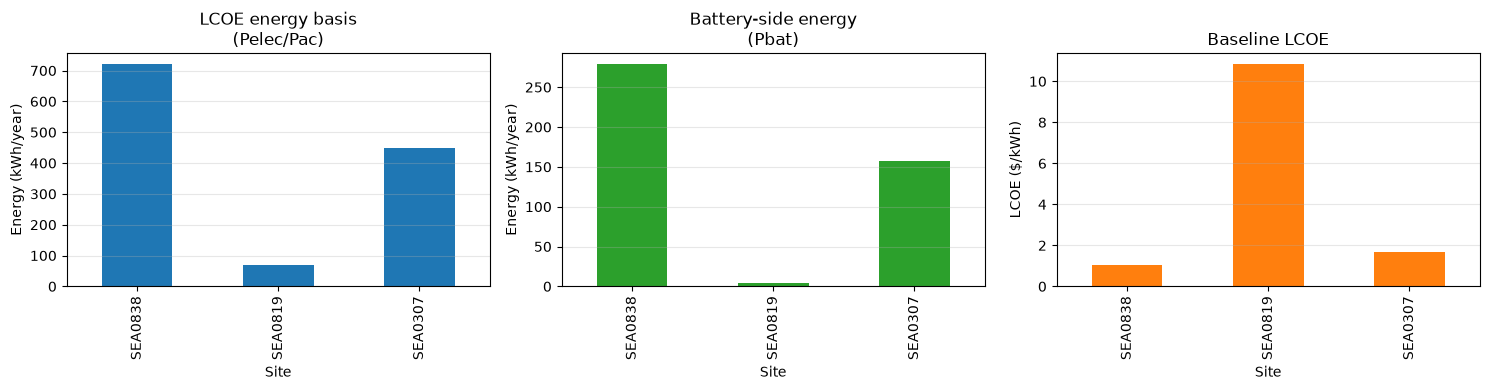

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

baseline_summary_df.plot(
    x="Site",
    y="LCOE energy, Pelec/Pac (kWh/yr)",
    kind="bar",
    ax=ax[0],
    legend=False,
    color="tab:blue",
)
ax[0].set_ylabel("Energy (kWh/year)")
ax[0].set_title("LCOE energy basis\n(Pelec/Pac)")
ax[0].grid(True, axis="y", alpha=0.3)

baseline_summary_df.plot(
    x="Site",
    y="Battery energy, Pbat (kWh/yr)",
    kind="bar",
    ax=ax[1],
    legend=False,
    color="tab:green",
)
ax[1].set_ylabel("Energy (kWh/year)")
ax[1].set_title("Battery-side energy\n(Pbat)")
ax[1].grid(True, axis="y", alpha=0.3)

baseline_summary_df.plot(
    x="Site",
    y="LCOE ($/kWh)",
    kind="bar",
    ax=ax[2],
    legend=False,
    color="tab:orange",
)
ax[2].set_ylabel("LCOE ($/kWh)")
ax[2].set_title("Baseline LCOE")
ax[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The same baseline design performs very differently across the three Sitkana sites. ``SEA0838`` produces the most energy and the lowest LCOE, while ``SEA0819`` produces much less energy and therefore a much higher LCOE. ``SEA0307`` falls between the two.

This illustrates an important point: site selection matters as much as turbine design. Even when the turbine configuration is held fixed, tidal resource strength strongly affects energy production and cost.

Because this is a battery-charging case study, the table reports both the energy used by the current LCOE calculation and an estimated battery-side delivered energy:

- ``LCOE energy, Pelec/Pac``: annual energy used by the current LCOE workflow.
- ``Battery energy, Pbat``: estimated annual energy delivered after power-electronics losses.

The difference between these values highlights the effect of power-conversion losses. Users interested specifically in delivered battery energy should review whether ``Pbat`` is the more appropriate energy metric for their analysis.

The values shown here are representative outputs used to demonstrate the software workflow and are not final engineering estimates.

## 6. Optimization across all three sites

Next, we optimize the baseline design for each of the three Sitkana candidate sites.

The optimizer performs an explicit grid search over selected design variables. In this case study, we vary:

- rotor radius,
- rated power.

For simplicity, hub depth and turbine count are held fixed.

For each candidate design, the optimizer:

1. updates the turbine configuration,
2. runs the rotor simulation,
3. checks physical constraints,
4. calculates LCOE for feasible designs,
5. identifies the lowest-LCOE feasible design within the selected search bounds.

This helps show how the preferred design changes with site conditions and how the battery-charging cost model responds to different turbine sizes.

In [10]:
variable_bounds = {
    "Radius": (0.5, 2.0, 0.5),          # 0.5, 1.0, 1.5, 2.0 m
    "Prated": (500.0, 1500.0, 500.0),   # 500, 1000, 1500 W
}

fixed_params = {
    "dHub": baseline_config["dHub"],
    "number_of_turbines": baseline_config["number_of_turbines"],
}

# Count grid points for user awareness
num_grid_points = 1
for low, high, step in variable_bounds.values():
    values = np.arange(low, high + 0.5 * step, step)
    num_grid_points *= len(values)

print(f"Optimization grid size per site: {num_grid_points} design points")

opt_results = {}

for label, tidal_site in sites.items():
    print(f"\n=== Running optimization for {label} ({tidal_site.station_name}) ===")

    optimizer = LCOEOptimizer(
        tidal=tidal_site,
        rotor=rotor,
        base_config=baseline_config,
        user_vessel_properties=user_vessel_properties,
    )

    site_params = {
        "dMoor": tidal_site.mooring_distance,
        "Uinf": tidal_site.flow_speeds,
        "t": tidal_site.times,
    }

    try:
        # Suppress detailed per-design-point output for a cleaner case-study notebook.
        with contextlib.redirect_stdout(io.StringIO()):
            opt_result = optimizer.optimize(
                variable_bounds=variable_bounds,
                fixed_params=fixed_params,
                site_params=site_params,
                customer="customer_B",
                application="battery_charging",
                BatteryCapacity_kWh=10.0,
                lifetime=10,
                discount_rate=0.1,
                turbulence_intensity=0.0,
            )

        opt_results[label] = {
            "optimizer": optimizer,
            "result": opt_result,
        }

        print(f"  Optimal LCOE: ${opt_result['optimal_lcoe']:.4f}/kWh")
        print(
            f"  Feasible designs: "
            f"{len(opt_result['feasible_table'])} of {len(opt_result['results_table'])}"
        )

        print("  Optimal variable values:")
        for name, value in opt_result["optimal_params"].items():
            print(f"    {name}: {value}")

    except Exception as e:
        print(f"  Optimization failed for {label}: {e}")
        opt_results[label] = {
            "optimizer": optimizer,
            "result": None,
        }

Optimization grid size per site: 12 design points

=== Running optimization for SEA0838 (Lituya Bay Entrance) ===


  Optimal LCOE: $1.0352/kWh
  Feasible designs: 5 of 12
  Optimal variable values:
    Radius: 0.5
    Prated: 1000.0

=== Running optimization for SEA0819 (North Pass, Lincoln Island) ===


  Optimal LCOE: $8.8398/kWh
  Feasible designs: 6 of 12
  Optimal variable values:
    Radius: 0.5
    Prated: 500.0

=== Running optimization for SEA0307 (Tracy Arm) ===


  Optimal LCOE: $1.3584/kWh
  Feasible designs: 6 of 12
  Optimal variable values:
    Radius: 0.5
    Prated: 500.0
